In [ ]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to label strokes in video

In [ ]:
def label_video(video_path: str, save_csv: str):
    cap = cv2.VideoCapture(video_path)
    df = pd.read_csv(save_csv)

    frame_count = 0
    labels = {}
    stroke_window = 30 # each stroke is about 30 frames long
    frames_remaining = 0
    current_stroke = 'Neutral'

    while cap.isOpened():
        sucess, frame =  cap.read()
        
        if not sucess:
            break
        
        #shows the frame in the video
        cv2.imshow("Video" ,frame)
        
        #waits 50 ms between frames, slowing it down
        key = cv2.waitKey(50) & 0xFF
        
        #checks if frame needs to be labeled from previous labels
        if frames_remaining > 0:
            frame_label = current_stroke
            frames_remaining -= 1
        else: 
            frame_label = "Neutral"
            
        #print(f"Capturing {frame_label}")
            
        #stores each frame as a stroke in the dict. default is neutral    
        labels[frame_count] = frame_label
        
        #allows me to mark the beginning of the stroke by pressing the key and the 29 frames following
        if key == ord('q'):
            print("Quit pressed")
            break
        elif key == ord('f'):
            print(f"Forehand at {frame_count}")
            frames_remaining = stroke_window
            current_stroke = labels[frame_count] = "Forehand" #overrides the Neutral frame assignment from above
        elif key == ord('b'):
            print(f"Backhand at {frame_count}")
            frames_remaining = stroke_window
            current_stroke = labels[frame_count] = "Backhand"
        elif key == ord('s'):
            print(f"Serve at {frame_count}")
            frames_remaining = 45 # serving is a longer stroke than most
            current_stroke = labels[frame_count] = "Serve"
        elif key == ord('n'):
            print(f"Neutral at {frame_count}")
            frames_remaining = 0
            current_stroke = labels[frame_count] = "Neutral"
        
        frame_count += 1
        
    cap.release()
    cv2.destroyAllWindows()

    #write the labels into the csv
    df['label'] = df['frame'].map(labels).fillna('Neutral')
    df.to_csv(save_csv, index=False)
    print(f"Read {frame_count} frames")
    print(f"\nLabel Counts:")
    print(df['label'].value_counts())
    return df

# Function to plot coords from labeled strokes

In [ ]:
def plot_wrist_by_label(df, title):    
    color_map = {
        'Neutral': '#aaaaaa',
        'Forehand': '#32DC32',
        'Backhand': '#32B4FF',
        'Serve': '#FFA032',
    }

    fig, ax = plt.subplots(figsize=(10, 5)) #creates a 10 in x 5 in pic

    for label, group in df.groupby('label'): #groups all the unqiue labels together
        ax.scatter( #make a scatterplot for each label
            group['RIGHT_WRIST_x'],
            group['RIGHT_WRIST_y'],
            alpha=0.3,
            s=8,
            color=color_map.get(label, '#ffffff'),  #finds the color from the dict
            label=label
        )

    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Labeling vids and plotting them


In [ ]:
##uncomment if you want to relabel strokes in vids

# df_forehand = label_video("../2_pose_extraction/training_vid/forehand_train.mp4",
#                            "../2_pose_extraction/stroke_csv/forehand_landmarks.csv")
# df_backhand = label_video("../2_pose_extraction/training_vid/backhand_train.mp4",
#                            "../2_pose_extraction/stroke_csv/backhand_landmarks.csv")
# df_match = label_video("../2_pose_extraction/training_vid/match_train.mp4",
#                           "../2_pose_extraction/stroke_csv/match_landmarks.csv")


In [ ]:
#run this if vids are alr labeled and saved to csv

df_forehand = pd.read_csv("../2_pose_extraction/stroke_csv/forehand_landmarks.csv")
df_backhand = pd.read_csv("../2_pose_extraction/stroke_csv/backhand_landmarks.csv")
df_match = pd.read_csv("../2_pose_extraction/stroke_csv/match_landmarks.csv")

In [ ]:
# print(df_forehand['label'].value_counts())
# print(df_backhand['label'].value_counts())
# print(df_match['label'].value_counts())

#combines all csv into one
df_all = pd.concat([df_match, df_backhand, df_forehand], ignore_index = True)
df_all.to_csv("../2_pose_extraction/stroke_csv/all_landmarks.csv", index = False)
print(f"Total rows: {len(df_all)}")
print(df_all['label'].value_counts())

Total rows: 6386
label
Neutral     4327
Backhand    1070
Serve        506
Forehand     483
Name: count, dtype: int64


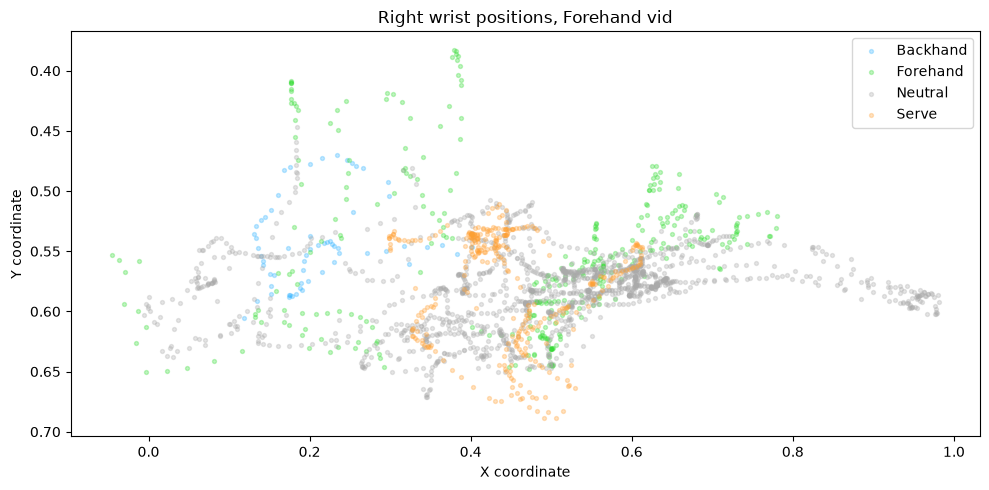

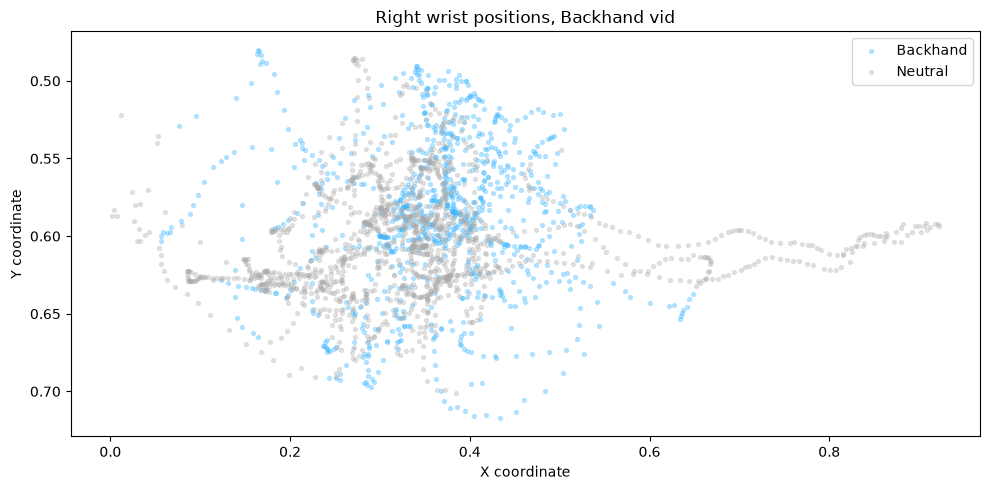

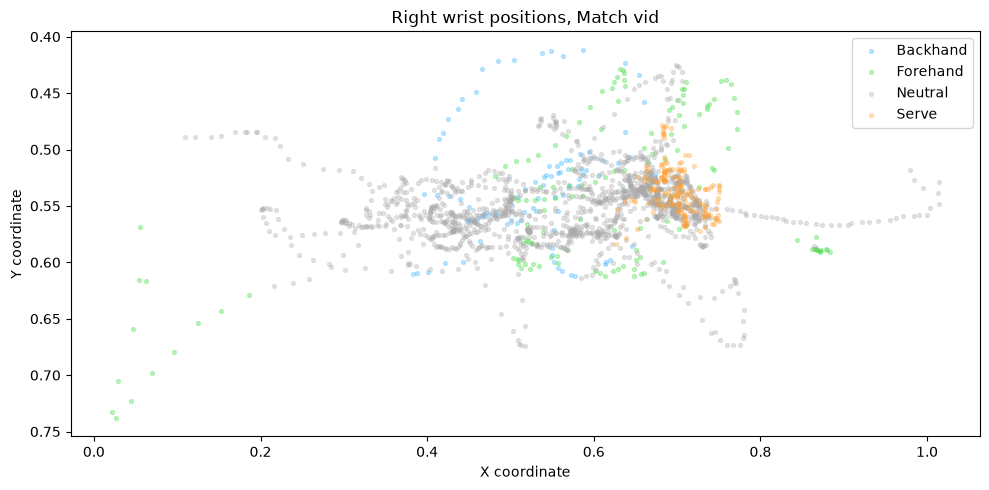

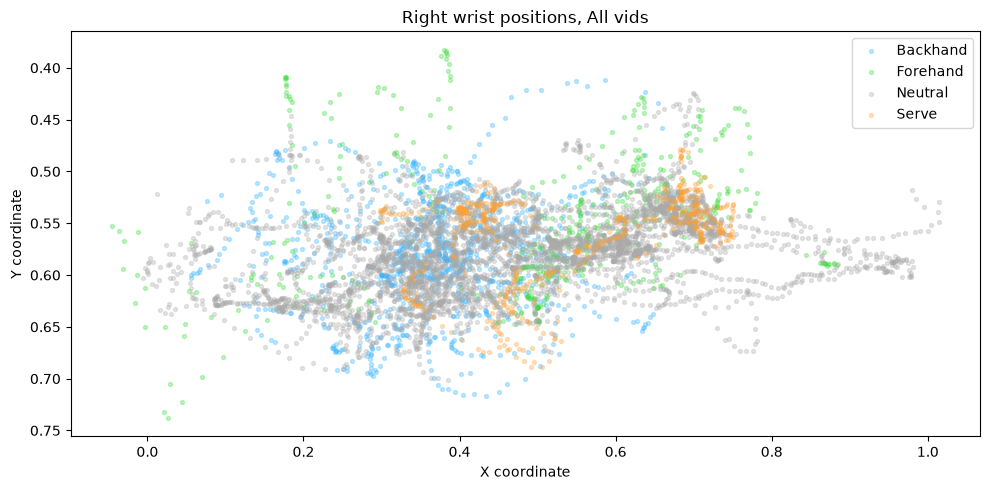

In [69]:
plot_wrist_by_label(df_forehand, "Right wrist positions, Forehand vid")
plot_wrist_by_label(df_backhand, "Right wrist positions, Backhand vid")
plot_wrist_by_label(df_match, "Right wrist positions, Match vid")
plot_wrist_by_label(df_all, "Right wrist positions, All vids")
